# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

**Project:** Bluestock Mutual Fund Analytics Capstone

**Prepared By:** Bhargavi

## Objective
The objective of this notebook is to perform Exploratory Data Analysis (EDA) on cleaned mutual fund datasets. The analysis identifies trends, patterns, and insights using statistical summaries and visualizations.

In [118]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [119]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folios = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [120]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folios:", folios.shape)
print("Performance:", performance.shape)
print("Investor:", investor.shape)
print("Portfolio:", portfolio.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folios: (21, 6)
Performance: (40, 20)
Investor: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [121]:
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


In [122]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [123]:
datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Performance": performance,
    "Investor": investor,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV
amfi_code    0
date         0
nav          0
dtype: int64

AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

Category
month               0
category            0
net_inflow_crore    0
dtype: int64

Folios
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
o

In [124]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [125]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


# Exploratory Data Analysis (EDA)

The following section presents visualizations and insights derived from the cleaned mutual fund datasets.

In [126]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Merge NAV with Fund Master to get scheme names
nav_df = pd.merge(
    nav,
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Display first 5 rows
nav_df.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [127]:
print("Shape:", nav_df.shape)

print("\nColumns:")
print(nav_df.columns)

print("\nNumber of Mutual Fund Schemes:")
print(nav_df["scheme_name"].nunique())

print("\nDate Range:")
print(nav_df["date"].min())
print(nav_df["date"].max())

Shape: (46000, 4)

Columns:
Index(['amfi_code', 'date', 'nav', 'scheme_name'], dtype='str')

Number of Mutual Fund Schemes:
40

Date Range:
2022-01-03 00:00:00
2026-05-29 00:00:00


## 1. NAV Trend Analysis

This visualization shows the daily NAV movement for all 40 mutual fund schemes from 2022 to 2026. The chart highlights the 2023 market bull run and the 2024 market correction.

In [128]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction"
)

fig.update_layout(
    template="plotly_white",
    width=1400,
    height=800,
    xaxis_title="Date",
    yaxis_title="Net Asset Value (NAV)",
    legend_title="Scheme Name",
    legend=dict(
        orientation="v",
        y=1,
        x=1.02,
        font=dict(size=10)
    )
)

fig.show()

In [129]:
fig.write_image("../reports/charts/nav_trend.png", scale=2)

### Insight 1

The NAV of most mutual fund schemes showed an overall upward trend during 2023, indicating strong market performance. Increased volatility and corrections were observed during 2024 before recovery in subsequent periods.

**Supporting Chart:** Chart 1 – Daily NAV Trend Analysis

In [130]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [131]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

## 2. AUM Growth Analysis

This chart compares the Assets Under Management (AUM) of major fund houses from 2022 to 2025. It highlights the growth of each fund house over time, with a focus on SBI Mutual Fund's market leadership.

In [164]:
# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Display sample data
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


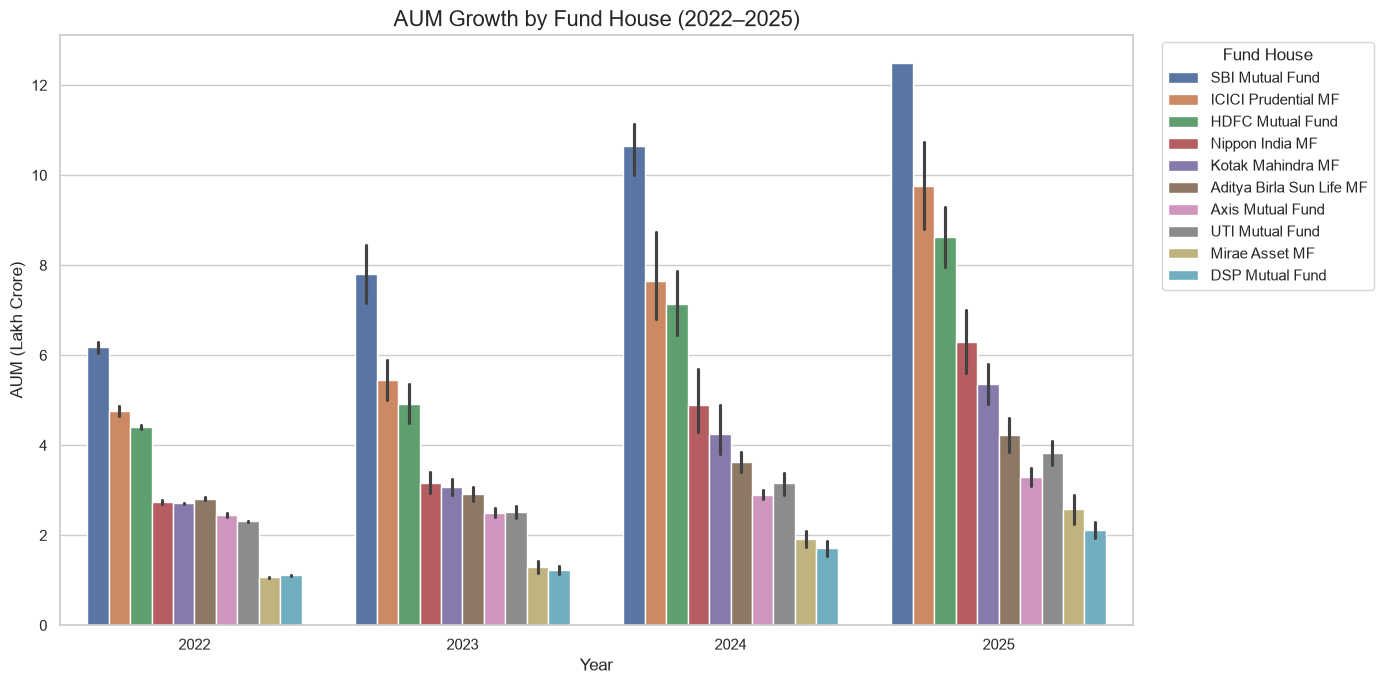

Chart saved successfully!


In [165]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

# SAVE FIRST
plt.savefig("../reports/charts/aum_growth.png", dpi=300, bbox_inches="tight")

# THEN DISPLAY
plt.show()

print("Chart saved successfully!")

In [134]:
plt.savefig("../reports/charts/aum_growth.png", dpi=300, bbox_inches="tight")

print("AUM Growth chart saved successfully!")

AUM Growth chart saved successfully!


<Figure size 640x480 with 0 Axes>

### Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among the selected fund houses, demonstrating its strong market presence and investor confidence.

**Supporting Chart:** Chart 2 – AUM Growth Analysis

## 3. Monthly SIP Inflow Trend

This chart illustrates the monthly SIP (Systematic Investment Plan) inflows from January 2022 to December 2025, highlighting the all-time high recorded in December 2025.

In [135]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [136]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [137]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Verify
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [138]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

# Find highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Convert Timestamp to string
max_month = max_row["month"].strftime("%Y-%m-%d")

fig.add_annotation(
    x=max_month,
    y=max_row["sip_inflow_crore"],
    text=f"Highest SIP Inflow<br>₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [139]:
fig.write_image("../reports/charts/sip_inflow_trend.png", scale=2)

print("SIP Inflow Trend chart saved successfully!")

SIP Inflow Trend chart saved successfully!


### Insight 3

Monthly SIP inflows increased steadily from January 2022 to December 2025, reflecting growing investor participation and confidence in mutual funds. The highest monthly SIP inflow of **₹31,002 crore** was recorded in **December 2025**, indicating a record level of systematic investments.

**Supporting Chart:** Chart 3 – Monthly SIP Inflow Trend

## 4. Category-wise Net Inflow Heatmap

This heatmap visualizes the monthly net inflows across different mutual fund categories. Darker colors indicate higher net inflows, making it easier to identify investment trends over time.

In [140]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [141]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [142]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Convert month to Month-Year format
category["month"] = category["month"].dt.strftime("%b-%Y")

# Create pivot table for heatmap
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


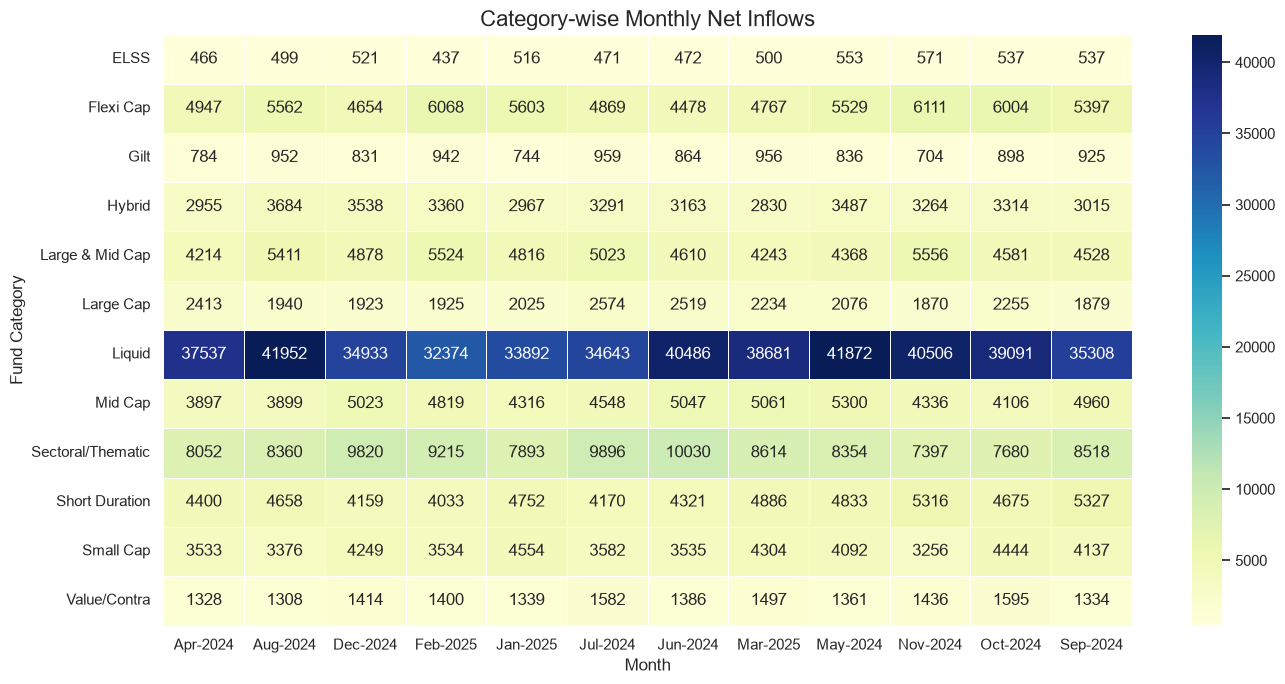

Category Heatmap saved successfully!


In [143]:
plt.figure(figsize=(14,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflows", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

# Save BEFORE showing
plt.savefig("../reports/charts/category_inflow_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("Category Heatmap saved successfully!")

### Insight 4

Net inflows varied across mutual fund categories over time. Flexi Cap, Mid Cap, and Large & Mid Cap funds attracted comparatively higher inflows during several months, indicating strong investor preference for diversified and growth-oriented equity categories.

**Supporting Chart:** Chart 4 – Category-wise Net Inflow Heatmap

## 5. Investor Demographics Analysis

This section analyzes investor demographics based on age group, gender, and SIP investment behavior.

In [144]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


In [145]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

## 5. Investor Demographics

This section analyzes investor demographics based on age group, gender, investment amount, and geographical distribution.

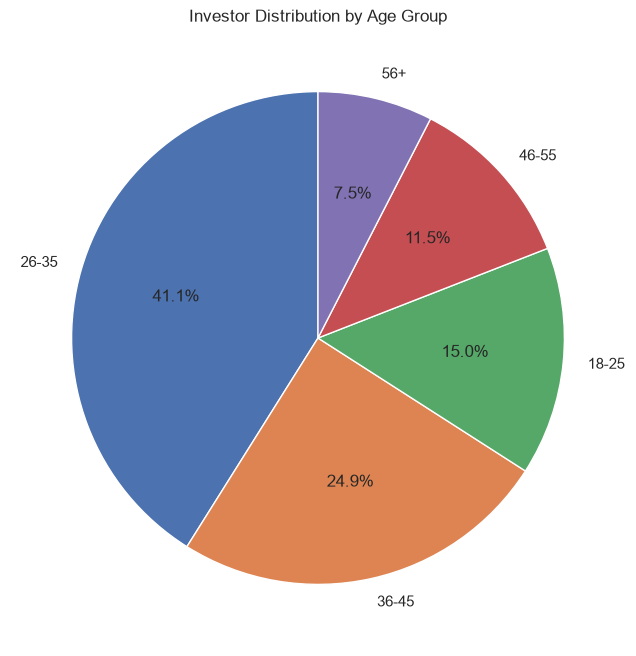

In [146]:
age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

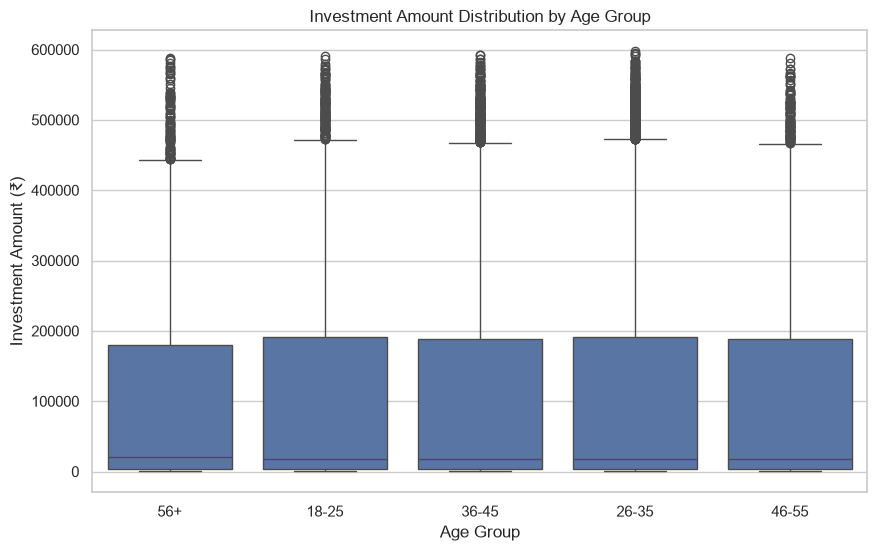

In [147]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.savefig(
    "../reports/charts/age_group_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

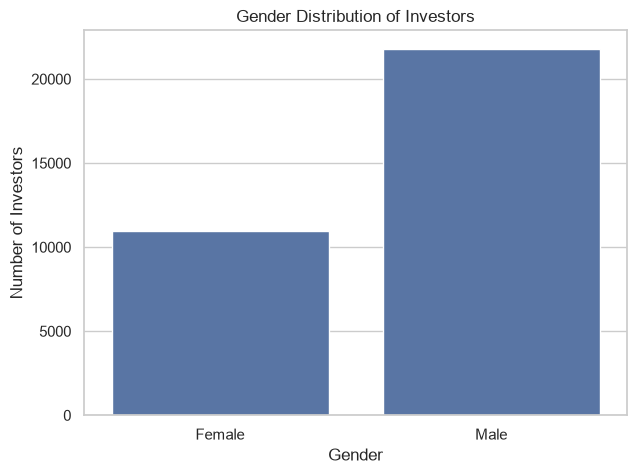

In [148]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=investor,
    x="gender"
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5

The investor base is distributed across multiple age groups, with the highest participation coming from working-age individuals. Investment amounts also vary considerably between age groups, while the gender distribution highlights overall participation patterns within the dataset.

**Supporting Charts:**
- Chart 5 – Age Group Distribution
- Chart 6 – Investment Amount by Age Group
- Chart 7 – Gender Distribution

## 6. Geographic Distribution Analysis

This section analyzes the geographic distribution of mutual fund investments across Indian states and compares investor participation between T30 and B30 cities.

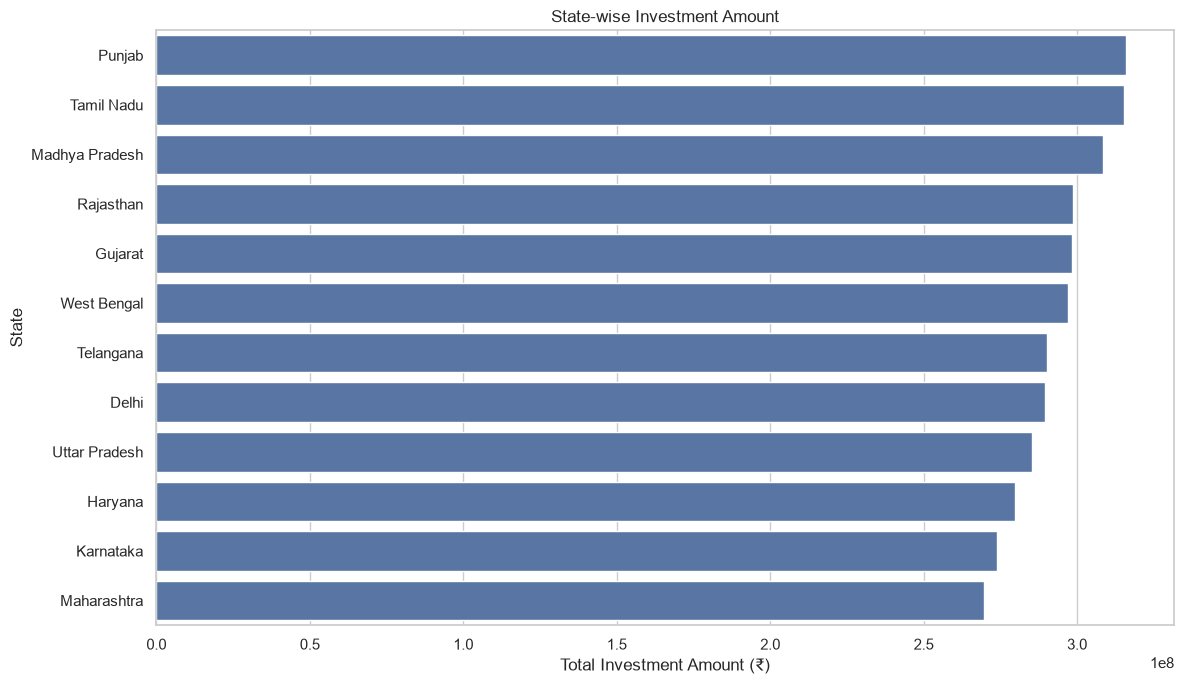

In [149]:
# Aggregate investment amount by state
state_data = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("State-wise Investment Amount")
plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_wise_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

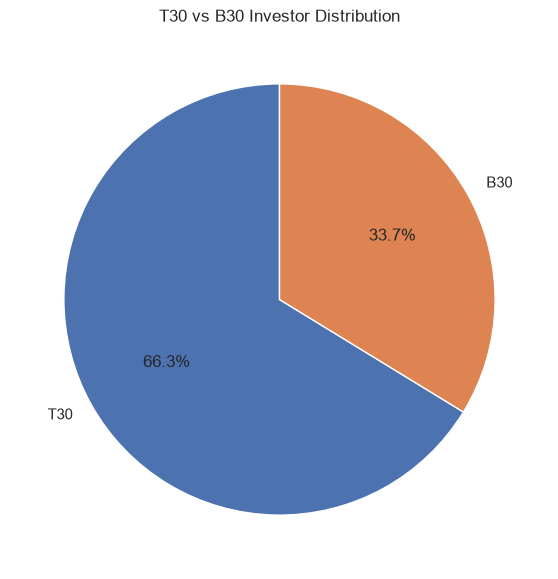

In [150]:
tier_counts = investor["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6

Investment activity is concentrated in a few major states, while T30 cities account for a larger share of investors than B30 cities. This indicates stronger mutual fund penetration in metropolitan regions.

**Supporting Charts:**
- Chart 8 – State-wise Investment Distribution
- Chart 9 – T30 vs B30 Distribution

## 7. Folio Count Growth Analysis

This chart illustrates the growth in mutual fund folio counts over time, highlighting the increasing participation of investors in the mutual fund industry.

In [151]:
folios.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [152]:
folios.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

# Convert month to datetime
folios["month"] = pd.to_datetime(folios["month"])

folios.head()

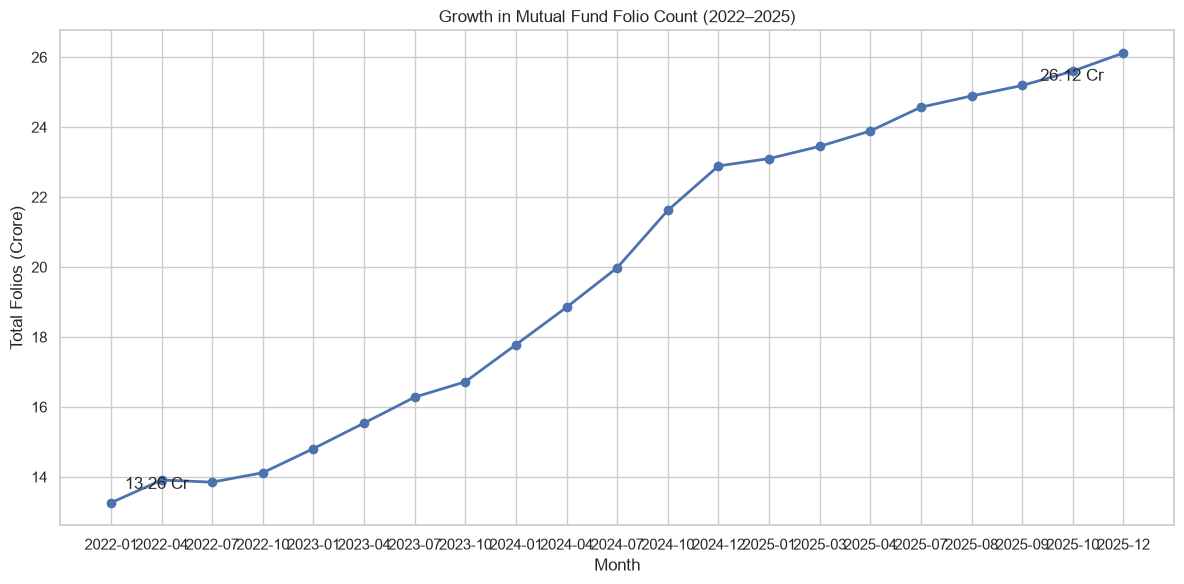

In [153]:
plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o",
    linewidth=2
)

# Mark first and last values
plt.annotate(
    "13.26 Cr",
    xy=(folios["month"].iloc[0], folios["total_folios_crore"].iloc[0]),
    xytext=(10,10),
    textcoords="offset points"
)

plt.annotate(
    "26.12 Cr",
    xy=(folios["month"].iloc[-1], folios["total_folios_crore"].iloc[-1]),
    xytext=(-60,-20),
    textcoords="offset points"
)

plt.title("Growth in Mutual Fund Folio Count (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

# Save first
plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 7

The total number of mutual fund folios increased significantly between 2022 and 2025, reflecting a steady rise in investor participation. Folio counts nearly doubled over the analysis period, indicating strong growth in the mutual fund industry.

**Supporting Chart:** Chart 10 – Folio Count Growth

## 8. NAV Return Correlation Matrix

This heatmap shows the correlation of daily NAV returns among 10 selected mutual fund schemes.

In [154]:
# Pivot NAV data
nav_pivot = nav_df.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Select first 10 schemes
nav_pivot = nav_pivot.iloc[:, :10]

# Daily returns
returns = nav_pivot.pct_change().dropna()

returns.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
date,,,,,,,,,,
2022-01-04,0.001153,-0.000141,-0.010865,-0.000187,-0.006561,-0.003597,0.018757,0.000482,-0.010498,-0.008592
2022-01-05,0.003866,0.000382,0.000603,-0.002863,-0.007511,0.016595,0.019898,0.008670,-0.002593,-0.006480
2022-01-06,-0.002128,-0.000143,-0.029101,-0.009811,0.009926,-0.000246,-0.000431,-0.013861,-0.008382,-0.003818
2022-01-07,-0.006314,0.000215,0.024766,0.008215,0.009331,-0.018524,0.032482,0.004317,0.011680,-0.004069
2022-01-10,0.011548,0.000690,0.001251,0.005685,-0.009961,-0.006878,0.026144,0.003650,0.001356,0.001601


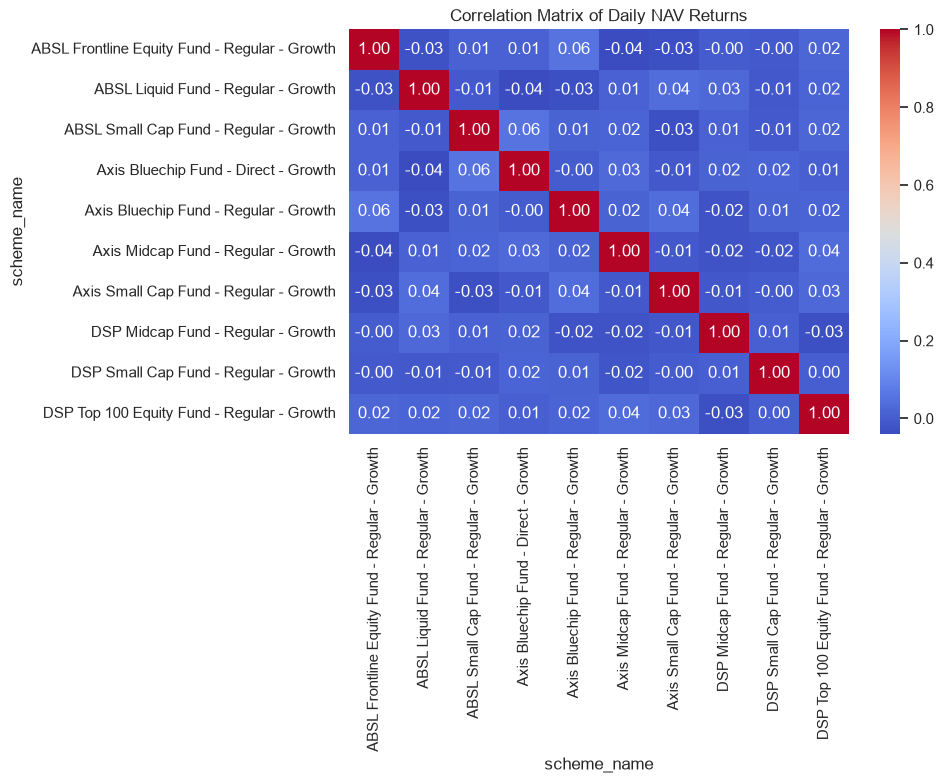

In [155]:
plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 8

Most equity-oriented mutual fund schemes exhibit a positive correlation in daily NAV returns, indicating similar responses to overall market movements. However, the correlation strength varies across different fund categories.

**Supporting Chart:** Chart 11 – NAV Return Correlation Matrix

## 9. Sector Allocation Analysis

This chart shows the aggregate sector allocation across all equity mutual funds based on portfolio holdings.

In [156]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [157]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

## 9. Sector Allocation Analysis

This donut chart shows the aggregate portfolio allocation across different sectors for the selected equity mutual funds.

In [158]:
# Aggregate sector weights
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

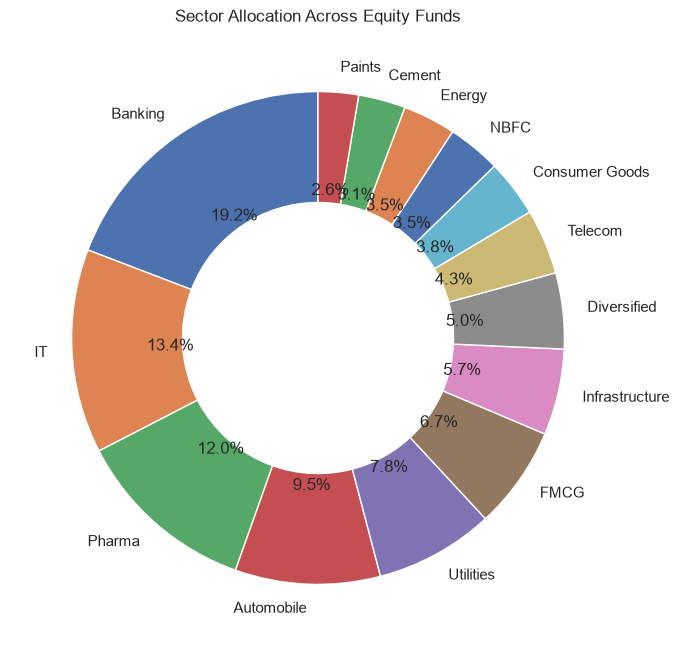

In [159]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "../reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 9

Banking, Utilities, Pharma, Diversified, and other core sectors constitute a significant portion of the mutual fund portfolios, indicating diversification across major industries.

**Supporting Chart:** Chart 12 – Sector Allocation Analysis

## 10. Transaction Type Distribution

This chart illustrates the distribution of different mutual fund transaction types performed by investors.

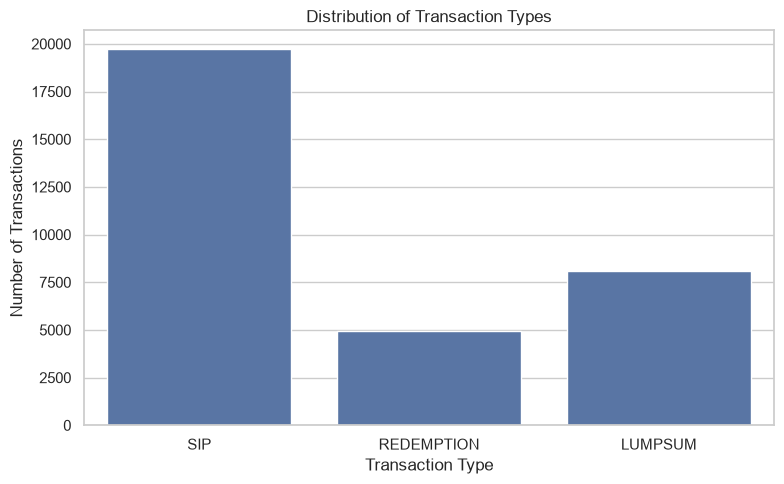

In [160]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=investor,
    x="transaction_type"
)

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    "../reports/charts/transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Risk Category Distribution

This chart shows the number of mutual fund schemes across different risk categories.

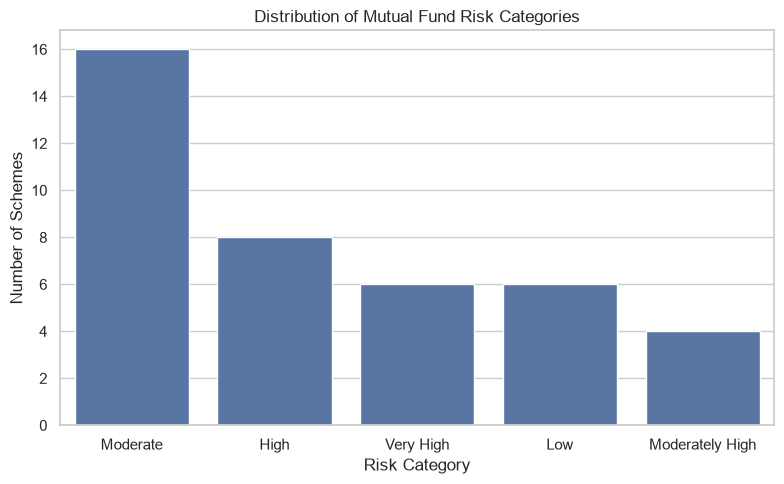

In [161]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="risk_category",
    order=fund_master["risk_category"].value_counts().index
)

plt.title("Distribution of Mutual Fund Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")

plt.tight_layout()

plt.savefig(
    "../reports/charts/risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Scheme Category Distribution

This chart presents the distribution of mutual fund schemes across different investment categories.

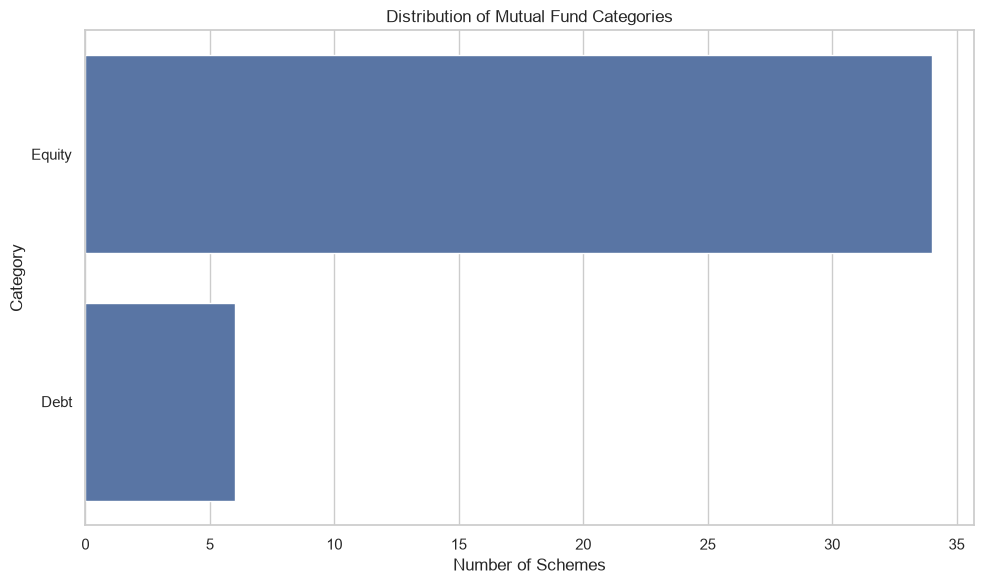

In [162]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=fund_master,
    y="category",
    order=fund_master["category"].value_counts().index
)

plt.title("Distribution of Mutual Fund Categories")
plt.xlabel("Number of Schemes")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/scheme_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 10

Mutual fund offerings are concentrated in equity-oriented schemes, with a broad range of risk categories and transaction types supporting diverse investor preferences.

**Supporting Charts:**
- Chart 13 – Transaction Type Distribution
- Chart 14 – Risk Category Distribution
- Chart 15 – Scheme Category Distribution

# Conclusion

This Exploratory Data Analysis (EDA) examined multiple aspects of the mutual fund industry, including NAV trends, AUM growth, SIP inflows, investor demographics, geographic distribution, folio growth, sector allocation, and fund characteristics. The analysis shows steady industry growth, increasing investor participation, strong SIP inflows, and diversified portfolio allocations across sectors and categories. These insights provide a comprehensive overview of mutual fund performance and investor behavior during the analysis period.

In [163]:
import os

charts_folder = "../reports/charts"

files = sorted(os.listdir(charts_folder))

print(f"Total charts: {len(files)}\n")

for file in files:
    print(file)

Total charts: 15

age_group_boxplot.png
age_group_distribution.png
aum_growth.png
category_inflow_heatmap.png
folio_growth.png
gender_distribution.png
nav_correlation_matrix.png
nav_trend.png
risk_category_distribution.png
scheme_category_distribution.png
sector_allocation_donut.png
sip_inflow_trend.png
state_wise_investment.png
t30_b30_distribution.png
transaction_type_distribution.png
